# Growth of *N. glabratus* Evolved Populations in Tested Temperatures

Here we plot the OD600s of N. glabratus populations that were
experimentally evolved at 40°C or 35°C, plus the ancestral strain (fRS585), 
assayed at 25°C, 35°C, 38°C, 41°C, and 42°C.

Input: Table_S1.xlsx

## Imports and configuration

In [2]:
import datetime
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.optimize import curve_fit
from openpyxl import load_workbook
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

#Directories
DATA_PATH = './Table_S1.xlsx'
OUT       = Path('Processed_Outputs')
OUT.mkdir(exist_ok=True)

#Plots formatting
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.weight':       'bold',
    'axes.labelweight':  'bold',
    'axes.titleweight':  'bold',
    'figure.dpi':        150,
})

EVO_COLORS = {
    '40°C Evolved': '#FA3208',
    '35°C Evolved': '#0E63FF',
    'Ancestor':      '#000000',
}

## Parse strain key and OD600 data

In [5]:
#Well-strain mapping from 'Key' sheet in the .xlsx input
wb = load_workbook(DATA_PATH, read_only=True)
ws_key    = wb['Key']
key_rows  = list(ws_key.iter_rows(values_only=True))
well_to_strain = {1: {}, 2: {}, 3: {}}

for row in key_rows[6:]:
    if row[0] is None: continue
    for block_idx, (loc_col, strain_col) in enumerate([(0,1),(2,3),(4,5)], start=1):
        loc    = row[loc_col]
        strain = row[strain_col]
        if loc and strain and strain != 'Strain Dropped':
            for well in str(loc).split(','):
                well_to_strain[block_idx][well.strip()] = strain

print('Well→strain mappings:', {b: len(d) for b,d in well_to_strain.items()})


#OD600 time-series from temperature sheets
def time_to_hours(t):
    if isinstance(t, datetime.time):
        return t.hour + t.minute/60 + t.second/3600
    elif isinstance(t, datetime.timedelta):
        return t.total_seconds()/3600
    return np.nan


def parse_temp_sheet(ws, temp_label, well_to_strain):
    rows   = list(ws.iter_rows(values_only=True))
    records = []
    block_starts = [(i, int(row[0].split()[1]))
                    for i, row in enumerate(rows)
                    if isinstance(row[0], str) and row[0].startswith('BLOCK')]
    for bi, (start_idx, block_num) in enumerate(block_starts):
        header   = rows[start_idx + 1]
        well_cols = {ci: header[ci] for ci in range(2, len(header)) if header[ci]}
        end_idx  = block_starts[bi+1][0] if bi+1 < len(block_starts) else len(rows)
        for row in rows[start_idx+2:end_idx]:
            if row[0] is None: continue
            t_h = time_to_hours(row[0])
            if np.isnan(t_h): continue
            for ci, well in well_cols.items():
                od = row[ci] if ci < len(row) else None
                if od is None or not isinstance(od, (int, float)): continue
                records.append({'block': block_num, 'well': well,
                                'strain': well_to_strain[block_num].get(well),
                                'time_h': t_h, 'OD': float(od), 'temp': temp_label})
    return pd.DataFrame(records)

temp_dfs = []
for sheet, label in [('25C',25),('35C',35),('38C',38),('41C',41),('42C',42)]:
    df_t = parse_temp_sheet(wb[sheet], label, well_to_strain)
    temp_dfs.append(df_t)
    print(f'  {sheet}: {df_t.shape[0]:,} rows')

df_all = pd.concat(temp_dfs, ignore_index=True)
df_all = df_all.dropna(subset=['strain']).copy()
df_all['OD'] = df_all['OD'].clip(lower=1e-4)

# Assign evolution history
def assign_evo(strain):
    if strain.startswith('40_'):   return '40°C Evolved'
    if strain.startswith('35_'):   return '35°C Evolved'
    if 'fRS585' in strain:         return 'Ancestor'
    return 'Other'

df_all['evo_history'] = df_all['strain'].apply(assign_evo)

Well→strain mappings: {1: 39, 2: 39, 3: 39}
  25C: 27,936 rows
  35C: 27,936 rows
  38C: 27,936 rows
  41C: 27,936 rows
  42C: 27,936 rows


## Plot the raw OD600 growth curves

One averaged line per population by assay temperature. This is partly a
visual QC check before estimating growth rate.

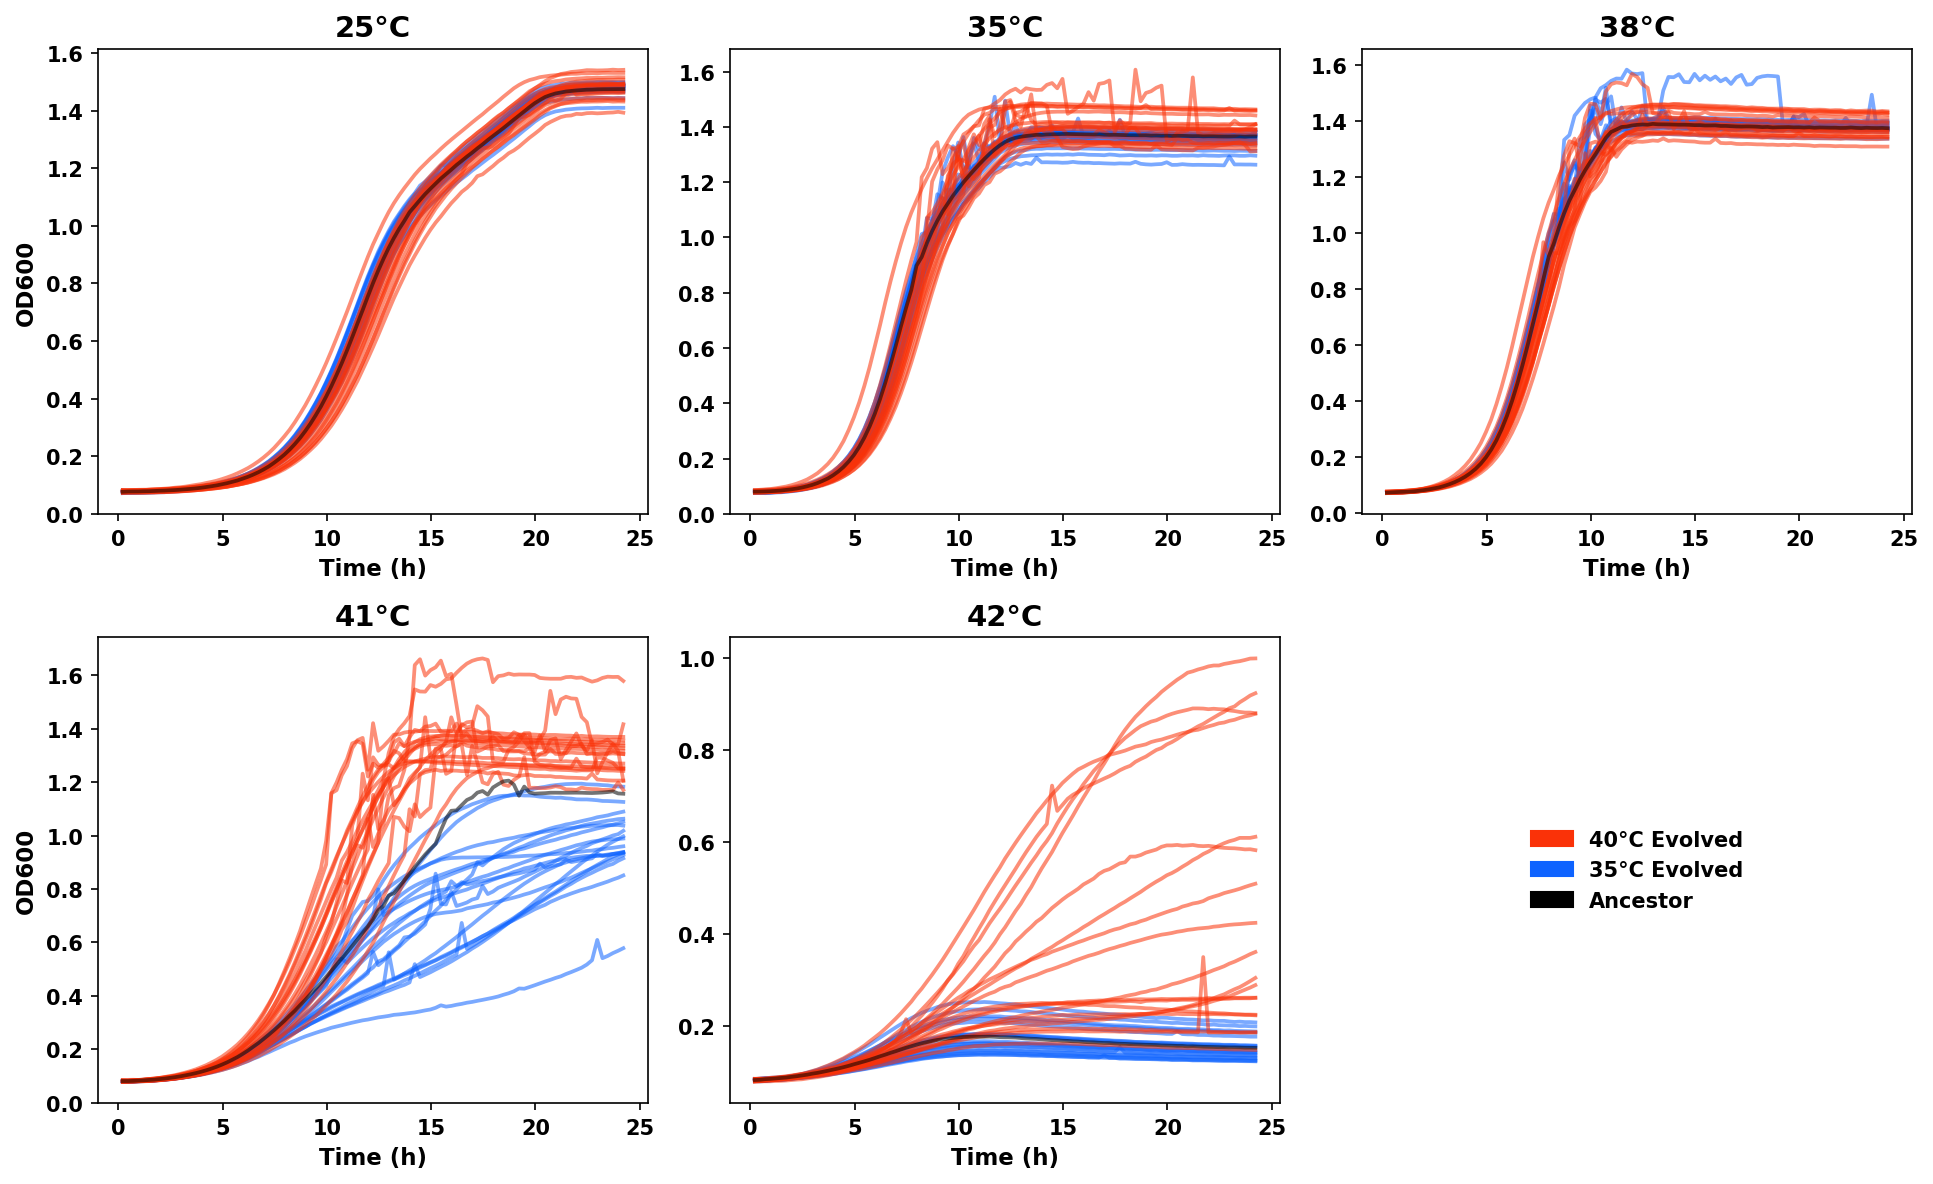

In [8]:
PRIMARY = ['40°C Evolved', '35°C Evolved', 'Ancestor']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = axes.flatten()

for ax, temp in zip(axes_flat[:5], [25, 35, 38, 41, 42]):
    sub = df_all[(df_all['temp']==temp) & (df_all['evo_history'].isin(PRIMARY))]
    sub_avg = sub.groupby(['strain','evo_history','time_h'])['OD'].mean().reset_index()
    for (strain, evo), grp in sub_avg.groupby(['strain','evo_history']):
        ax.plot(grp['time_h'], grp['OD'],
                color=EVO_COLORS.get(evo,'#AAAAAA'), alpha=0.55, lw=1.8)
    ax.set_title(f'{temp}°C', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (h)', fontsize=11, fontweight='bold')
    if temp in (25, 41):
        ax.set_ylabel('OD600', fontsize=11, fontweight='bold')

#Legend in the place of a 6th panel
handles = [mpatches.Patch(color=EVO_COLORS[g], label=g) for g in PRIMARY]
axes_flat[-1].legend(handles=handles, loc='center', fontsize=10, frameon=False)
axes_flat[-1].axis('off')

plt.tight_layout()
plt.savefig(OUT / 'qc_raw_curves.png', bbox_inches='tight', dpi=150)
plt.show()